# Advanced EDA 02 — Stationarity, Unit Roots & Cointegration
**Referencias:** Hamilton (1994) *Time Series Analysis*, Cap. 15–17 · Engle & Granger (1987) · Phillips & Perron (1988) · Johansen (1988)

## ¿Por qué importa la estacionariedad?
Una serie no estacionaria tiene media/varianza que cambian en el tiempo. Regresar una serie I(1) sobre otra I(1) sin verificar cointegración produce **regresión espuria** (Granger & Newbold, 1974): $R^2$ alto y t-stats significativos que son artefactos estadísticos.

## Definiciones (Hamilton, 1994, Cap. 15)
- **Proceso estrictamente estacionario**: la distribución conjunta de $(y_t, y_{t+k})$ no depende de $t$
- **Proceso débilmente estacionario (covarianza-estacionario)**: $E[y_t] = \mu$, $Var(y_t) = \sigma^2 < \infty$, $Cov(y_t, y_{t-k}) = \gamma_k$ (solo depende del lag $k$)
- **Proceso I(1)**: tiene una raíz unitaria → diferenciarlo una vez produce un proceso estacionario I(0)

## Modelo de raíz unitaria
$$y_t = \rho y_{t-1} + u_t$$
- Si $|\rho| < 1$: estacionario (AR(1) estable)
- Si $\rho = 1$: **raíz unitaria** → random walk, no estacionario

## Cointegración (Engle & Granger, 1987)
Dos series I(1) están **cointegradas** si existe una combinación lineal $z_t = y_t - \alpha - \beta x_t$ que es I(0). Implica una relación de largo plazo estable — el **vector de cointegración** $(1, -\beta)$.

In [1]:
import os
os.chdir('/Volumes/SSD_Gabo/proyectos/growth-analytics')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller, kpss, coint
from statsmodels.tsa.vector_ar.vecm import coint_johansen
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import acf, pacf

plt.rcParams.update({
    'figure.dpi': 130, 'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.color': '#e8e8e8', 'axes.axisbelow': True,
    'axes.titlesize': 11, 'axes.titleweight': 'bold', 'legend.frameon': False,
})
np.random.seed(42)

T = 500   # períodos
t = np.arange(T)

# Serie estacionaria: AR(1) con ρ=0.7
y_stationary = np.zeros(T)
for i in range(1, T):
    y_stationary[i] = 0.7 * y_stationary[i-1] + np.random.normal(0, 1)

# Serie con tendencia determinista
y_trend = 0.05 * t + np.random.normal(0, 1, T).cumsum() * 0.3

# Random Walk I(1) — raíz unitaria
y_rw = np.cumsum(np.random.normal(0, 1, T))

# Series cointegradas: y2 = 0.5 + 1.5*y1 + estacionario
y1 = np.cumsum(np.random.normal(0, 1, T))
spread_stationary = np.zeros(T)
for i in range(1, T):
    spread_stationary[i] = 0.6 * spread_stationary[i-1] + np.random.normal(0, 0.5)
y2 = 0.5 + 1.5 * y1 + spread_stationary

# Series NO cointegradas: dos random walks independientes
y3 = np.cumsum(np.random.normal(0, 1, T))
y4 = np.cumsum(np.random.normal(0, 1, T))

print('Series generadas:')
print('  y_stationary: AR(1) ρ=0.7 → I(0)')
print('  y_rw:         Random Walk → I(1)')
print('  y1, y2:       Random Walks cointegradas')
print('  y3, y4:       Random Walks NO cointegradas (regresión espuria)')

Series generadas:
  y_stationary: AR(1) ρ=0.7 → I(0)
  y_rw:         Random Walk → I(1)
  y1, y2:       Random Walks cointegradas
  y3, y4:       Random Walks NO cointegradas (regresión espuria)


## 1 — Visualización: estacionaria vs no estacionaria

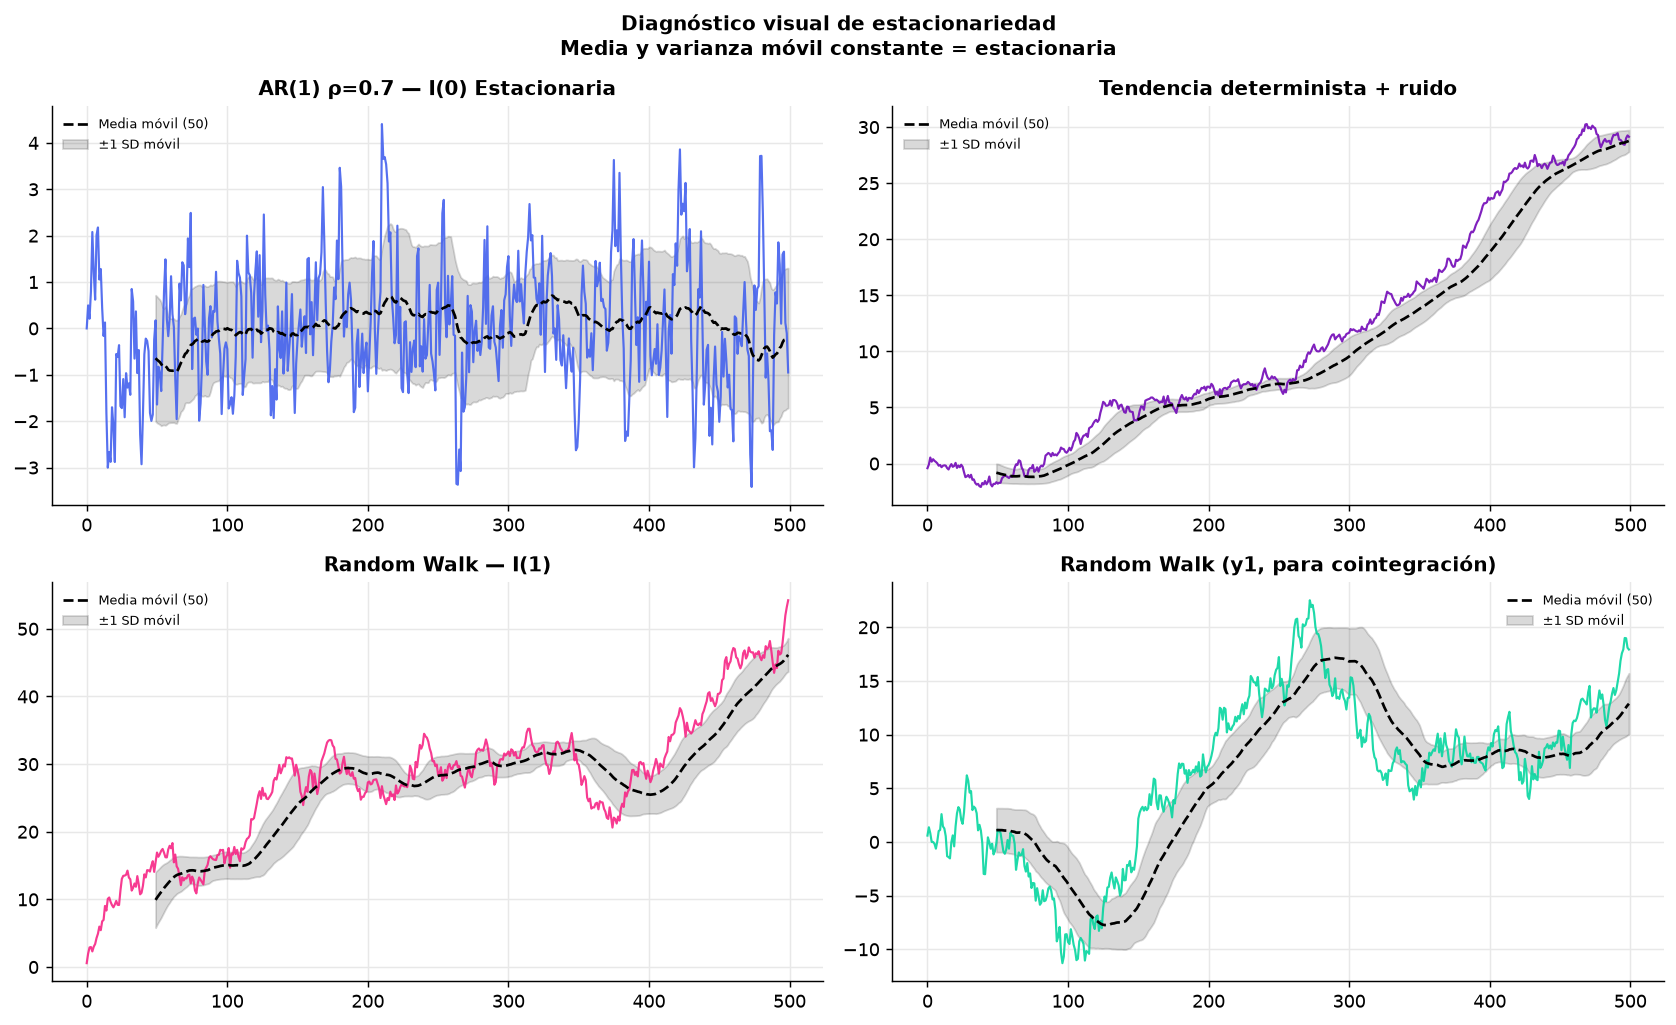

In [2]:
fig, axes = plt.subplots(2, 2, figsize=(13, 8))

series_list = [
    (y_stationary, 'AR(1) ρ=0.7 — I(0) Estacionaria',    '#4361ee'),
    (y_trend,      'Tendencia determinista + ruido',        '#7209b7'),
    (y_rw,         'Random Walk — I(1)',                    '#f72585'),
    (y1,           'Random Walk (y1, para cointegración)', '#06d6a0'),
]

for ax, (series, title, color) in zip(axes.flatten(), series_list):
    ax.plot(series, color=color, linewidth=1.2, alpha=0.9)
    # Rolling mean y std para diagnosticar estacionariedad visual
    roll_mean = pd.Series(series).rolling(50).mean()
    roll_std  = pd.Series(series).rolling(50).std()
    ax.plot(roll_mean, color='black', linewidth=1.5, linestyle='--', label='Media móvil (50)')
    ax.fill_between(range(T), roll_mean - roll_std, roll_mean + roll_std,
                    alpha=0.15, color='black', label='±1 SD móvil')
    ax.set_title(title)
    ax.legend(fontsize=7)

plt.suptitle('Diagnóstico visual de estacionariedad\nMedia y varianza móvil constante = estacionaria',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

## 2 — Augmented Dickey-Fuller Test (1979, 1981)

Testea $H_0: \rho = 1$ (raíz unitaria) vs $H_1: |\rho| < 1$ (estacionaria).

La regresión aumentada controla autocorrelación serial:
$$\Delta y_t = \alpha + \delta t + \gamma y_{t-1} + \sum_{j=1}^p \phi_j \Delta y_{t-j} + u_t$$
$H_0$: $\gamma = 0$ (raíz unitaria). Distribución no estándar (Dickey-Fuller, 1979).

**Phillips-Perron (1988):** alternativa no-paramétrica que corrige autocorrelación sin agregar lags.

In [3]:
def adf_summary(series, name, maxlag=None):
    """Corre ADF con constante, con tendencia, y en primeras diferencias."""
    results = {}
    for reg, label in [('c', 'Constante'), ('ct', 'Constante+Tendencia')]:
        adf_stat, p_val, lags, nobs, crit, _ = adfuller(series, regression=reg, maxlag=maxlag)
        results[label] = {'stat': adf_stat, 'p': p_val, 'lags': lags,
                          'crit_5%': crit['5%']}
    # En primeras diferencias
    diff_series = np.diff(series)
    adf_stat_d, p_val_d, lags_d, _, crit_d, _ = adfuller(diff_series, regression='c')
    results['Δy (dif.)'] = {'stat': adf_stat_d, 'p': p_val_d, 'lags': lags_d,
                             'crit_5%': crit_d['5%']}
    print(f'\nADF — {name}')
    print(f'  {"Especificación":<22} {"ADF stat":>10} {"p-value":>9} {"Lags":>5} {"Crit 5%":>9} {"Decisión":>15}')
    for label, r in results.items():
        decision = 'Estacionaria' if r['p'] < 0.05 else 'Raíz unitaria'
        print(f'  {label:<22} {r["stat"]:>10.4f} {r["p"]:>9.4f} {r["lags"]:>5} {r["crit_5%"]:>9.4f} {decision:>15}')
    return results

print('═' * 75)
print('AUGMENTED DICKEY-FULLER TEST (Dickey & Fuller 1979, Said & Dickey 1984)')
print('H₀: Raíz unitaria (no estacionaria)')
print('═' * 75)

adf_summary(y_stationary, 'AR(1) estacionaria')
adf_summary(y_rw,         'Random Walk I(1)')
adf_summary(y_trend,      'Tendencia determinista')

═══════════════════════════════════════════════════════════════════════════
AUGMENTED DICKEY-FULLER TEST (Dickey & Fuller 1979, Said & Dickey 1984)
H₀: Raíz unitaria (no estacionaria)
═══════════════════════════════════════════════════════════════════════════

ADF — AR(1) estacionaria
  Especificación           ADF stat   p-value  Lags   Crit 5%        Decisión
  Constante                 -9.6296    0.0000     0   -2.8673    Estacionaria
  Constante+Tendencia       -9.6444    0.0000     0   -3.4193    Estacionaria
  Δy (dif.)                -11.0909    0.0000     9   -2.8675    Estacionaria

ADF — Random Walk I(1)
  Especificación           ADF stat   p-value  Lags   Crit 5%        Decisión
  Constante                 -1.1311    0.7025     0   -2.8673   Raíz unitaria
  Constante+Tendencia       -2.1836    0.4991     0   -3.4193   Raíz unitaria
  Δy (dif.)                -22.8266    0.0000     0   -2.8674    Estacionaria

ADF — Tendencia determinista
  Especificación           ADF stat 

{'Constante': {'stat': np.float64(1.0993423634856432),
  'p': np.float64(0.9952110059964353),
  'lags': 0,
  'crit_5%': np.float64(-2.867349510566146)},
 'Constante+Tendencia': {'stat': np.float64(-2.0572512201984092),
  'p': np.float64(0.5699358017652619),
  'lags': 0,
  'crit_5%': np.float64(-3.4193250509831676)},
 'Δy (dif.)': {'stat': np.float64(-22.45810110614179),
  'p': 0.0,
  'lags': 0,
  'crit_5%': np.float64(-2.8673612117611267)}}

## 3 — KPSS Test (Kwiatkowski, Phillips, Schmidt & Shin, 1992)

**Complementario al ADF**: invierte las hipótesis.
$$H_0: \text{estacionaria} \quad H_1: \text{raíz unitaria}$$

> **Estrategia recomendada (Hamilton 1994):** aplicar ADF y KPSS juntos. Si ADF rechaza $H_0$ *y* KPSS no rechaza $H_0$ → evidencia fuerte de estacionariedad. Si ambos rechazan → posible quiebre estructural.

In [4]:
def combined_test(series, name):
    adf_stat, adf_p, *_ = adfuller(series, regression='c')
    kpss_stat, kpss_p, *_ = kpss(series, regression='c', nlags='auto')

    adf_reject  = adf_p < 0.05    # rechaza H0: raíz unitaria → estacionaria
    kpss_reject = kpss_p < 0.05   # rechaza H0: estacionaria → raíz unitaria

    if adf_reject and not kpss_reject:
        conclusion = '✅ I(0) — Estacionaria'
    elif not adf_reject and kpss_reject:
        conclusion = '❌ I(1) — Raíz unitaria'
    elif not adf_reject and not kpss_reject:
        conclusion = '⚠️  Evidencia débil — posiblemente I(1)'
    else:
        conclusion = '⚠️  Conflicto — posible quiebre estructural'

    print(f'{name:<28} ADF p={adf_p:.4f}  KPSS p={kpss_p:.4f}  → {conclusion}')

print('ADF + KPSS — Diagnóstico combinado (Hamilton 1994)')
print('─' * 80)
combined_test(y_stationary, 'AR(1) ρ=0.7')
combined_test(y_rw,         'Random Walk')
combined_test(y_trend,      'Tendencia det.')
combined_test(np.diff(y_rw),'ΔRandom Walk')
combined_test(y1,           'y1 (cointeg.)')
combined_test(y2,           'y2 (cointeg.)')

ADF + KPSS — Diagnóstico combinado (Hamilton 1994)
────────────────────────────────────────────────────────────────────────────────
AR(1) ρ=0.7                  ADF p=0.0000  KPSS p=0.1000  → ✅ I(0) — Estacionaria
Random Walk                  ADF p=0.7025  KPSS p=0.0100  → ❌ I(1) — Raíz unitaria
Tendencia det.               ADF p=0.9952  KPSS p=0.0100  → ❌ I(1) — Raíz unitaria
ΔRandom Walk                 ADF p=0.0000  KPSS p=0.1000  → ✅ I(0) — Estacionaria
y1 (cointeg.)                ADF p=0.6880  KPSS p=0.0100  → ❌ I(1) — Raíz unitaria
y2 (cointeg.)                ADF p=0.6307  KPSS p=0.0100  → ❌ I(1) — Raíz unitaria


/var/folders/3m/z0qp5nwj1vlccby390hqt0kc0000gn/T/ipykernel_18028/319515356.py:3: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_stat, kpss_p, *_ = kpss(series, regression='c', nlags='auto')
/var/folders/3m/z0qp5nwj1vlccby390hqt0kc0000gn/T/ipykernel_18028/319515356.py:3: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_stat, kpss_p, *_ = kpss(series, regression='c', nlags='auto')
/var/folders/3m/z0qp5nwj1vlccby390hqt0kc0000gn/T/ipykernel_18028/319515356.py:3: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_stat, kpss_p, *_ = kpss(series, regression='c', nlags='auto')
/var/folders/3m/z0qp5nwj1vlccby390hqt0kc0000gn/T/

## 4 — ACF / PACF: identificación del orden de integración

El patrón del ACF permite diagnosticar estacionariedad y el tipo de proceso:
- **I(0) AR(p)**: ACF decae exponencialmente, PACF tiene corte en lag $p$
- **I(0) MA(q)**: ACF tiene corte en lag $q$, PACF decae exponencialmente  
- **I(1)**: ACF decae muy lentamente (casi no decrece) — señal clásica de raíz unitaria

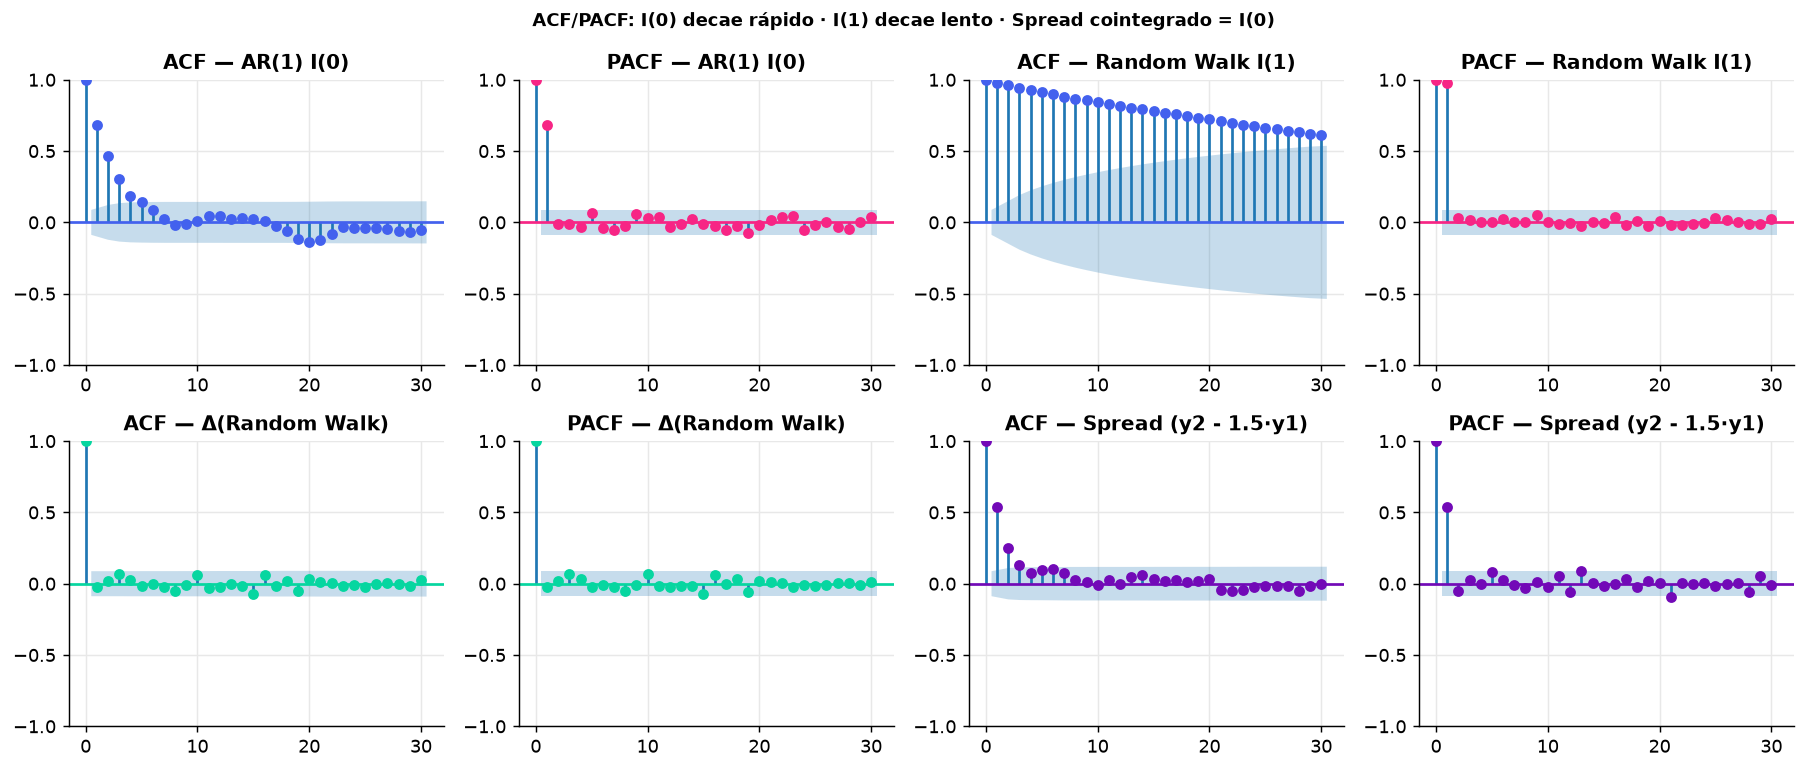

In [5]:
fig, axes = plt.subplots(2, 4, figsize=(14, 6))
lags = 30

series_pairs = [
    (y_stationary, 'AR(1) I(0)'),
    (y_rw,         'Random Walk I(1)'),
]

for col, (series, title) in enumerate(series_pairs):
    plot_acf(series,  lags=lags, ax=axes[0, col*2],
             color='#4361ee', title=f'ACF — {title}')
    plot_pacf(series, lags=lags, ax=axes[0, col*2+1],
              color='#f72585', title=f'PACF — {title}')

# Primeras diferencias del random walk
plot_acf(np.diff(y_rw),  lags=lags, ax=axes[1, 0],
         color='#06d6a0', title='ACF — Δ(Random Walk)')
plot_pacf(np.diff(y_rw), lags=lags, ax=axes[1, 1],
          color='#06d6a0', title='PACF — Δ(Random Walk)')

# Spread de series cointegradas
spread = y2 - 1.5 * y1
plot_acf(spread,  lags=lags, ax=axes[1, 2],
         color='#7209b7', title='ACF — Spread (y2 - 1.5·y1)')
plot_pacf(spread, lags=lags, ax=axes[1, 3],
          color='#7209b7', title='PACF — Spread (y2 - 1.5·y1)')

plt.suptitle('ACF/PACF: I(0) decae rápido · I(1) decae lento · Spread cointegrado = I(0)',
             fontsize=10, fontweight='bold')
plt.tight_layout()
plt.show()

## 5 — Regresión Espuria (Granger & Newbold, 1974)

> "It is very common to see reported in applied econometric literature time series regression equations with an apparently high degree of fit [...] but which have no structural meaning" — Granger & Newbold (1974, p. 111)

Dos series I(1) no relacionadas producen $R^2$ altos y t-stats significativos por pura acumulación de shocks compartidos.

REGRESIÓN ESPURIA vs CORRECTA — Granger & Newbold (1974)
────────────────────────────────────────────────────────────
  Espuria  (y3 ~ y4 en niveles):     R²=0.0261  p(β)=0.0003  DW=0.022
  Correcta (Δy3 ~ Δy4):             R²=0.0035  p(β)=0.1895  DW=1.984

R² alto + DW bajo en la espuria → síntoma clásico de regresión espuria.
Regla: si DW << 2 en regresión de niveles → sospechar no-estacionariedad.


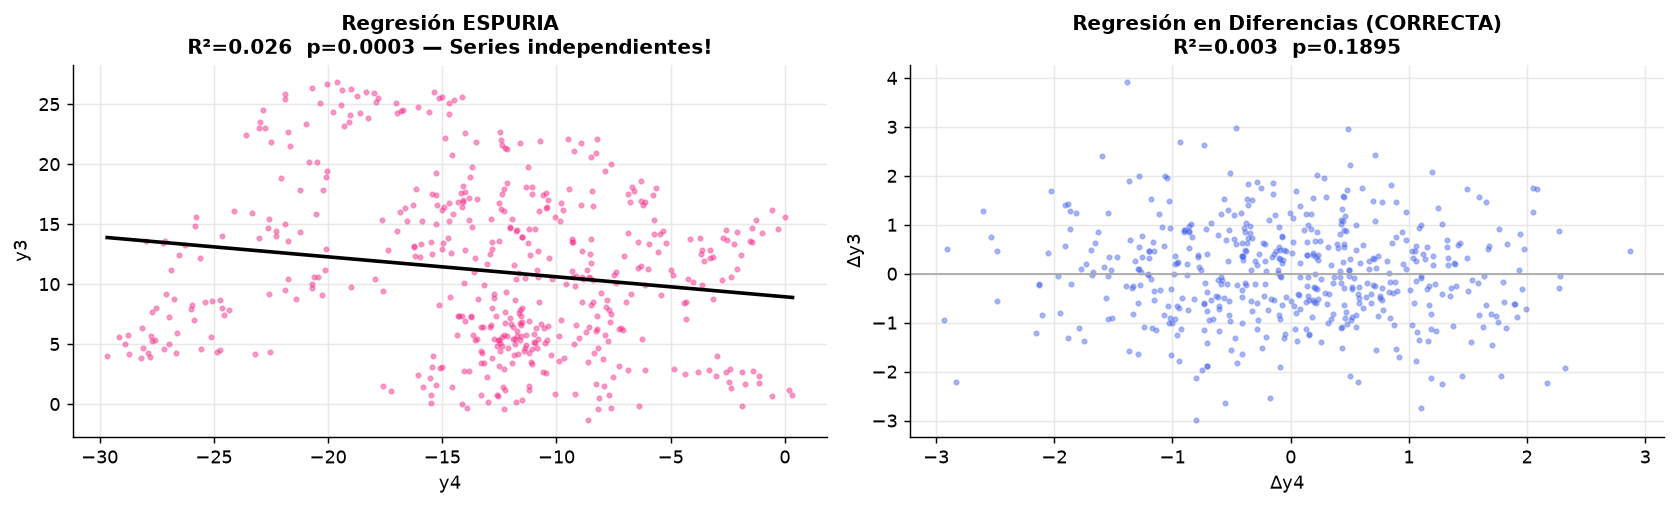

In [6]:
# Regresión espuria: y3 sobre y4 (series I(1) completamente independientes)
X_spur  = sm.add_constant(y4)
mod_spur = sm.OLS(y3, X_spur).fit()

# Regresión válida: Δy3 sobre Δy4 (diferenciadas → I(0))
X_diff  = sm.add_constant(np.diff(y4))
mod_diff = sm.OLS(np.diff(y3), X_diff).fit()

print('REGRESIÓN ESPURIA vs CORRECTA — Granger & Newbold (1974)')
print('─' * 60)
print(f'  Espuria  (y3 ~ y4 en niveles):     R²={mod_spur.rsquared:.4f}  p(β)={mod_spur.pvalues[1]:.4f}  DW={sm.stats.stattools.durbin_watson(mod_spur.resid):.3f}')
print(f'  Correcta (Δy3 ~ Δy4):             R²={mod_diff.rsquared:.4f}  p(β)={mod_diff.pvalues[1]:.4f}  DW={sm.stats.stattools.durbin_watson(mod_diff.resid):.3f}')
print()
print('R² alto + DW bajo en la espuria → síntoma clásico de regresión espuria.')
print('Regla: si DW << 2 en regresión de niveles → sospechar no-estacionariedad.')

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].scatter(y4, y3, s=6, alpha=0.4, color='#f72585')
axes[0].plot(np.sort(y4), mod_spur.params[0] + mod_spur.params[1]*np.sort(y4),
             color='black', linewidth=2)
axes[0].set_title(f'Regresión ESPURIA\nR²={mod_spur.rsquared:.3f}  p={mod_spur.pvalues[1]:.4f} — Series independientes!')
axes[0].set_xlabel('y4'); axes[0].set_ylabel('y3')

axes[1].scatter(np.diff(y4), np.diff(y3), s=6, alpha=0.4, color='#4361ee')
axes[1].axhline(0, color='#aaa', linewidth=1)
axes[1].set_title(f'Regresión en Diferencias (CORRECTA)\nR²={mod_diff.rsquared:.3f}  p={mod_diff.pvalues[1]:.4f}')
axes[1].set_xlabel('Δy4'); axes[1].set_ylabel('Δy3')
plt.tight_layout(); plt.show()

## 6 — Test de Cointegración: Engle-Granger (1987) y Johansen (1988)

**Engle-Granger (2 pasos):**
1. Regresar $y_t = \alpha + \beta x_t + \hat{u}_t$ (regresión de cointegración)
2. Testear ADF sobre $\hat{u}_t$. Si $\hat{u}_t \sim I(0)$ → cointegración

**Johansen (1988):** basado en VAR, permite múltiples vectores de cointegración.

TEST DE COINTEGRACIÓN — Engle & Granger (1987)
H₀: No cointegración
────────────────────────────────────────────────────────────
  y1 vs y2 (cointegradas):     t=-12.2559  p=0.0000  → Cointegradas ✅
  y3 vs y4 (independientes):   t=-1.8671  p=0.5966  → No cointeg. ✅

TEST DE JOHANSEN (1988) — rango de cointegración
  Estadístico de Traza:
  H₀: r≤0  stat=119.1130  crit 5%=15.4943  → Rechazar H₀
  H₀: r≤1  stat=1.3076  crit 5%=3.8415  → No rechazar


/Volumes/SSD_Gabo/proyectos/growth-analytics/.venv/lib/python3.13/site-packages/statsmodels/tsa/vector_ar/vecm.py:731: ComplexWarning: Casting complex values to real discards the imaginary part
  lr1[i] = -t * np.sum(tmp, 0)
/Volumes/SSD_Gabo/proyectos/growth-analytics/.venv/lib/python3.13/site-packages/statsmodels/tsa/vector_ar/vecm.py:732: ComplexWarning: Casting complex values to real discards the imaginary part
  lr2[i] = -t * np.log(1 - a[i])


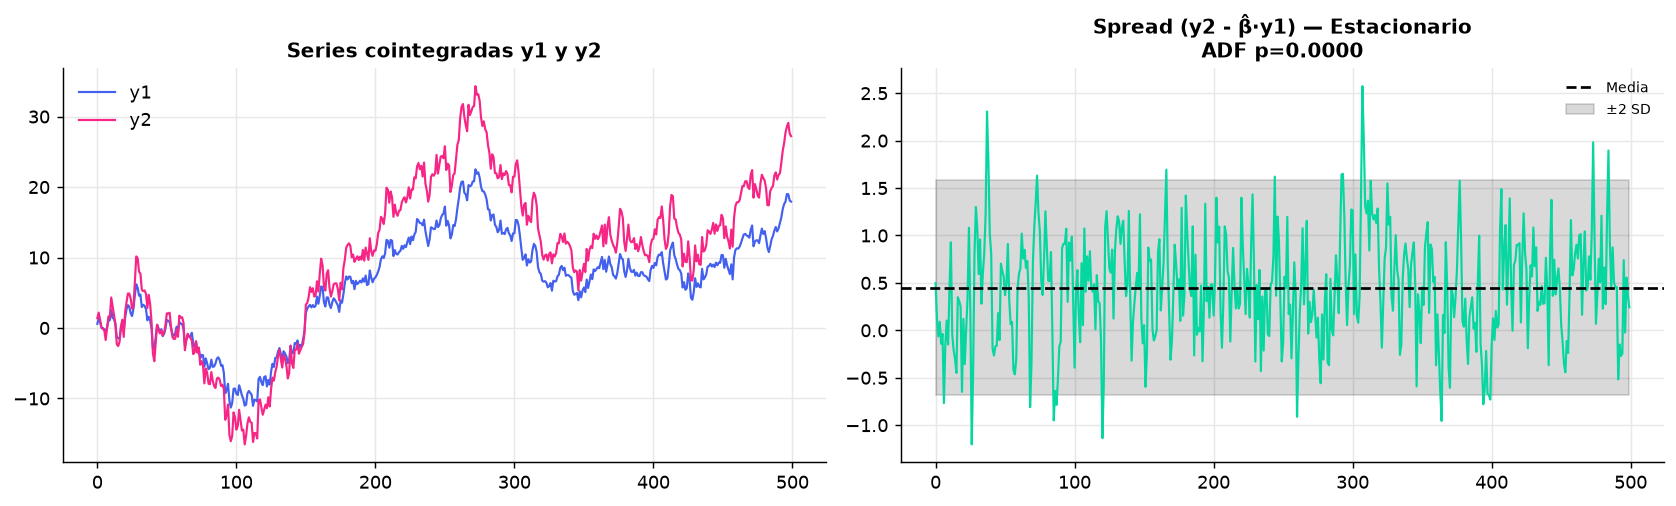

In [7]:
# Engle-Granger test
# statsmodels.coint: regresa y1 ~ y2, testea ADF en residuales
eg_t_coint, eg_p_coint, eg_crit = coint(y1, y2)
eg_t_spur,  eg_p_spur,  _       = coint(y3, y4)

print('TEST DE COINTEGRACIÓN — Engle & Granger (1987)')
print('H₀: No cointegración')
print('─' * 60)
print(f'  y1 vs y2 (cointegradas):     t={eg_t_coint:.4f}  p={eg_p_coint:.4f}  → {"Cointegradas ✅" if eg_p_coint < 0.05 else "No cointeg."}')
print(f'  y3 vs y4 (independientes):   t={eg_t_spur:.4f}  p={eg_p_spur:.4f}  → {"Cointegradas" if eg_p_spur < 0.05 else "No cointeg. ✅"}')

# Johansen test
print('\nTEST DE JOHANSEN (1988) — rango de cointegración')
data_coint = np.column_stack([y1, y2])
joh = coint_johansen(data_coint, det_order=0, k_ar_diff=1)
print('  Estadístico de Traza:')
for i, (stat, crit95) in enumerate(zip(joh.lr1, joh.cvt[:, 1])):
    decision = 'Rechazar H₀' if stat > crit95 else 'No rechazar'
    print(f'  H₀: r≤{i}  stat={stat:.4f}  crit 5%={crit95:.4f}  → {decision}')

# Visualizar spread de cointegración
X_coint = sm.add_constant(y1)
beta_hat = sm.OLS(y2, X_coint).fit().params[1]
spread_eg = y2 - beta_hat * y1

adf_spread, p_spread, *_ = adfuller(spread_eg, regression='c')

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(y1, color='#4361ee', linewidth=1.2, label='y1')
axes[0].plot(y2, color='#f72585', linewidth=1.2, label='y2')
axes[0].set_title('Series cointegradas y1 y y2')
axes[0].legend()

axes[1].plot(spread_eg, color='#06d6a0', linewidth=1.2)
axes[1].axhline(spread_eg.mean(), color='black', linestyle='--', linewidth=1.5, label='Media')
axes[1].fill_between(range(T),
                     spread_eg.mean() - 2*spread_eg.std(),
                     spread_eg.mean() + 2*spread_eg.std(),
                     alpha=0.15, color='black', label='±2 SD')
axes[1].set_title(f'Spread (y2 - β̂·y1) — Estacionario\nADF p={p_spread:.4f}')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

## 7 — Árbol de decisión: ¿qué hacer con series de tiempo?

```
¿ACF decae rápidamente?
  Sí → Serie probablemente I(0)
       Confirmar con ADF (p<0.05) + KPSS (p>0.05)
       → Modelar directamente (ARMA, OLS)

  No → Serie probablemente I(1)
       Confirmar con ADF (p>0.05) + KPSS (p<0.05)
       ¿Hay otra serie relacionada?
         Sí → Test de cointegración (Engle-Granger / Johansen)
                ¿Cointegradas?
                  Sí → Modelar con ECM (Error Correction Model)
                  No → Diferenciar → modelar Δy (ARIMA, VAR en diferencias)
         No → Diferenciar → modelar Δy
```

**Referencias:**
- Hamilton, J.D. (1994). *Time Series Analysis*. Princeton University Press.
- Engle, R.F. & Granger, C.W.J. (1987). Co-integration and error correction. *Econometrica*, 55(2).
- Granger, C.W.J. & Newbold, P. (1974). Spurious regressions in econometrics. *Journal of Econometrics*, 2(2).
- Dickey, D.A. & Fuller, W.A. (1979). Distribution of the estimators for autoregressive time series. *JASA*, 74(366).
- Kwiatkowski, D., Phillips, P.C.B., Schmidt, P. & Shin, Y. (1992). Testing the null hypothesis of stationarity. *Journal of Econometrics*, 54(1–3).
- Johansen, S. (1988). Statistical analysis of cointegration vectors. *Journal of Economic Dynamics and Control*, 12(2–3).
- Phillips, P.C.B. & Perron, P. (1988). Testing for a unit root in time series regression. *Biometrika*, 75(2).

**Siguiente:** `03_panel_data_diagnostics.ipynb`